Primeras 5 filas del dataset limpio:


,year,fuel,km_driven,owner,seller_type,selling_price,transmission
0,2014,Petrol,27000.0,0,Dealer,3.35,Manual
1,2013,Diesel,43000.0,0,Dealer,4.75,Manual
2,2017,Petrol,6900.0,0,Dealer,7.25,Manual
3,2011,Petrol,5200.0,0,Dealer,2.85,Manual
4,2014,Diesel,42450.0,0,Dealer,4.60,Manual



Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
Index: 13014 entries, 0 to 14827
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   year           13014 non-null  int64  
 1   fuel           13014 non-null  object 
 2   km_driven      13014 non-null  float64
 3   owner          13014 non-null  object 
 4   seller_type    13014 non-null  object 
 5   selling_price  13014 non-null  float64
 6   transmission   13014 non-null  object 
dtypes: float64(2), int64(1), object(4)
memory usage: 813.4+ KB

Estadísticas descriptivas:


,year,km_driven,selling_price
count,13014.000000,13014.000000,1.301400e+04
mean,2013.667896,63659.249424,4.522530e+05
std,4.060355,36735.955604,2.865254e+05
min,1983.000000,1.000000,1.000000e-01
25%,2011.000000,35000.000000,2.299990e+05
50%,2014.000000,60000.000000,4.000000e+05
75%,2017.000000,90000.000000,6.250000e+05
max,2022.000000,172000.000000,1.405000e+06


R²: 0.5723
MAE: 138959.87
RMSE: 183156.35


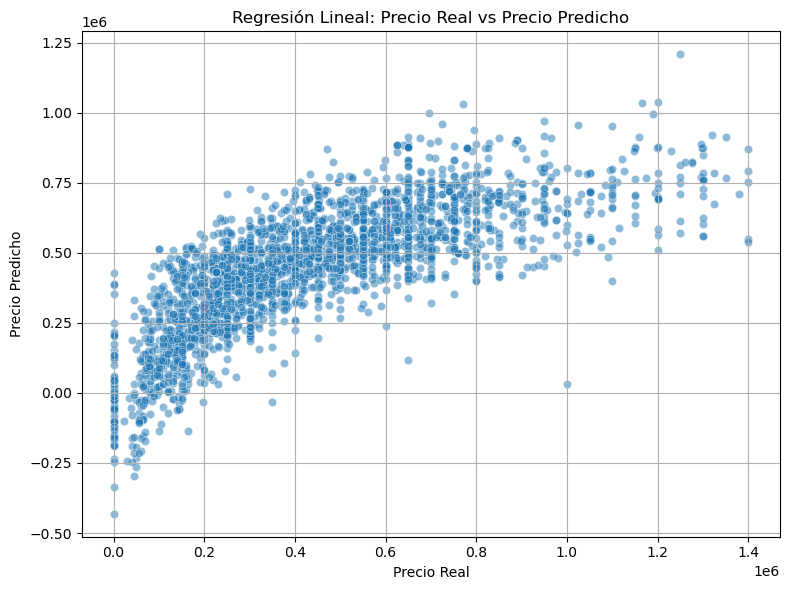

In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar archivos
df1 = pd.read_csv("car data.csv")
df2 = pd.read_csv("CAR DETAILS FROM CAR DEKHO.csv")
df3 = pd.read_csv("Car details v3.csv")
df4 = pd.read_csv("car details v4.csv")

# Renombrar columnas
df1 = df1.rename(columns={"Year": "year", "Fuel_Type": "fuel", "Kms_Driven": "km_driven",
                          "Owner": "owner", "Seller_Type": "seller_type",
                          "Selling_Price": "selling_price", "Transmission": "transmission"})
df4 = df4.rename(columns={"Fuel Type": "fuel", "Kilometer": "km_driven",
                          "Seller Type": "seller_type", "Owner": "owner", "Transmission": "transmission",
                          "Price": "selling_price", "Year": "year"})

# Columnas comunes
cols = ["year", "fuel", "km_driven", "owner", "seller_type", "selling_price", "transmission"]

# Unir datasets
df = pd.concat([
    df1[cols],
    df2[cols],
    df3[cols],
    df4[cols]
], ignore_index=True)

# --- LIMPIEZA ---

# Eliminar filas con nulos
df.dropna(inplace=True)

# Convertir 'km_driven' a numérico (remover comas o texto)
df["km_driven"] = df["km_driven"].astype(str).str.replace(r"[^\d]", "", regex=True).astype(float)

# Asegurar tipos correctos
df["year"] = pd.to_numeric(df["year"], errors='coerce')
df["selling_price"] = pd.to_numeric(df["selling_price"], errors='coerce')

# Eliminar nulos nuevamente
df.dropna(inplace=True)

# Eliminar outliers usando rango intercuartílico (IQR)
def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    return data[(data[column] >= Q1 - 1.5 * IQR) & (data[column] <= Q3 + 1.5 * IQR)]

for col in ["selling_price", "km_driven"]:
    df = remove_outliers_iqr(df, col)

# Codificar variables categóricas
df_encoded = pd.get_dummies(df, drop_first=True)

# SEPARAR X e y
X = df_encoded.drop("selling_price", axis=1)
y = df_encoded["selling_price"]

# TRAIN / TEST
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# MODELO
model = LinearRegression()
model.fit(X_train, y_train)

# PREDICCIÓN
y_pred = model.predict(X_test)


# Mostrar primeras filas del dataset
print("Primeras 5 filas del dataset limpio:")
display(df.head())

# Información general
print("\nInformación general del dataset:")
df.info()

# Estadísticas descriptivas
print("\nEstadísticas descriptivas:")
display(df.describe())

# MÉTRICAS
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R²:", round(r2, 4))
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))

# GRAFICO
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Regresión Lineal: Precio Real vs Precio Predicho")
plt.grid(True)
plt.tight_layout()
plt.show()